# Basic CNN Encoder for Time-Series Dimension Reduction

This notebook implements a small **1D convolutional autoencoder** for time-series dimension reduction.

The idea is simple:

- input: time series with shape `(n_samples, n_channels, sequence_length)`
- encoder: compresses each time series into a low-dimensional latent vector
- decoder: reconstructs the original time series from that vector
- latent vector: can be used for clustering, visualization, anomaly detection, or downstream ML

The dummy dataset can be replaced with real sensor, climate, displacement, or InSAR time-series data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Create a small synthetic time-series dataset

This section creates three simple classes of time series:

- seasonal signal
- trend + seasonal signal
- noisy irregular signal

For real data, replace `X` with your own NumPy array.

In [3]:
def make_synthetic_timeseries(n_samples=2700, seq_len=128):
    t = np.linspace(0, 1, seq_len)
    X = []
    labels = []

    for i in range(n_samples):
        kind = i % 3
        noise = 0.08 * np.random.randn(seq_len)

        if kind == 0:
            y = np.sin(2 * np.pi * 4 * t) + noise
        elif kind == 1:
            y = 0.8 * t + 0.5 * np.sin(2 * np.pi * 3 * t) + noise
        else:
            y = np.sin(2 * np.pi * 8 * t + np.random.rand()) * np.exp(-2 * t) + noise

        X.append(y)
        labels.append(kind)

    X = np.array(X, dtype=np.float32)
    labels = np.array(labels)
    return X, labels

X, labels = make_synthetic_timeseries()
X.shape, labels.shape

((2700, 128), (2700,))

In [4]:
# Standardize each time series globally across the dataset.
# For real data, consider whether per-series or global normalization makes more sense.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# PyTorch Conv1D expects: (samples, channels, sequence_length)
X_tensor = torch.tensor(X_scaled).unsqueeze(1)
X_tensor.shape

torch.Size([2700, 1, 128])

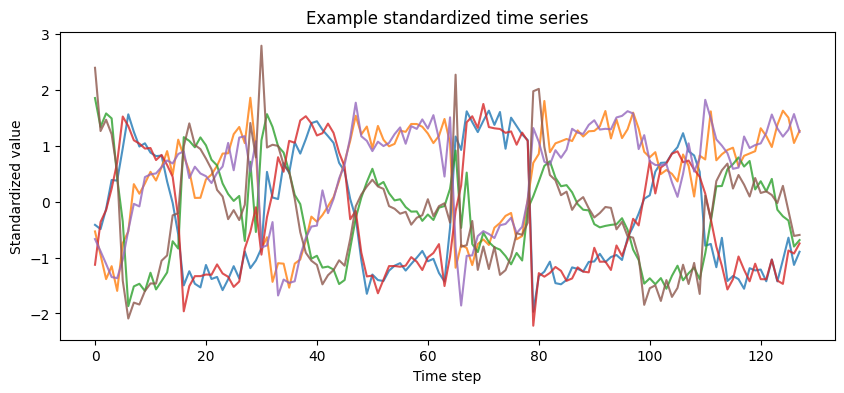

In [5]:
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.plot(X_scaled[i], alpha=0.8)
plt.title("Example standardized time series")
plt.xlabel("Time step")
plt.ylabel("Standardized value")
plt.show()

## 2. Prepare train/validation data

In [6]:
dataset = TensorDataset(X_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

## 3. Define a basic 1D CNN autoencoder

The encoder compresses the input sequence into a latent vector.
The decoder tries to reconstruct the original sequence.

For dimension reduction, the important output is the `z` vector from the encoder.

In [7]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, seq_len=128, latent_dim=8):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        # Infer flattened encoder size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_len)
            encoded = self.encoder_cnn(dummy)
            self.encoded_shape = encoded.shape[1:]
            flat_size = encoded.numel()

        self.encoder_fc = nn.Linear(flat_size, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, flat_size)

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2, padding=1),
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        h = h.view(h.size(0), -1)
        z = self.encoder_fc(h)
        return z

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(z.size(0), *self.encoded_shape)
        x_hat = self.decoder_cnn(h)

        # Make sure output length exactly matches input length
        x_hat = x_hat[:, :, :self.seq_len]
        return x_hat

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

model = Conv1DAutoencoder(seq_len=X_tensor.shape[-1], latent_dim=8).to(device)
model

Conv1DAutoencoder(
  (encoder_cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): ReLU()
  )
  (encoder_fc): Linear(in_features=1024, out_features=8, bias=True)
  (decoder_fc): Linear(in_features=8, out_features=1024, bias=True)
  (decoder_cnn): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 1, kernel_size=(4,), stride=(2,), padding=(1,))
  )
)

## 4. Train the autoencoder

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 30
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            loss = criterion(recon, batch)
            val_loss += loss.item() * batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1:02d}/{n_epochs} | train loss: {train_loss:.5f} | val loss: {val_loss:.5f}")

Epoch 01/30 | train loss: 0.58206 | val loss: 0.15976
Epoch 02/30 | train loss: 0.11512 | val loss: 0.09157
Epoch 03/30 | train loss: 0.08126 | val loss: 0.07260
Epoch 04/30 | train loss: 0.07159 | val loss: 0.06808
Epoch 05/30 | train loss: 0.06892 | val loss: 0.06668
Epoch 06/30 | train loss: 0.06783 | val loss: 0.06564
Epoch 07/30 | train loss: 0.06661 | val loss: 0.06473
Epoch 08/30 | train loss: 0.06514 | val loss: 0.06309
Epoch 09/30 | train loss: 0.06367 | val loss: 0.06194
Epoch 10/30 | train loss: 0.06217 | val loss: 0.06094
Epoch 11/30 | train loss: 0.06096 | val loss: 0.05980
Epoch 12/30 | train loss: 0.05950 | val loss: 0.05870
Epoch 13/30 | train loss: 0.05850 | val loss: 0.05797
Epoch 14/30 | train loss: 0.05762 | val loss: 0.05711
Epoch 15/30 | train loss: 0.05676 | val loss: 0.05628
Epoch 16/30 | train loss: 0.05614 | val loss: 0.05575
Epoch 17/30 | train loss: 0.05551 | val loss: 0.05513
Epoch 18/30 | train loss: 0.05509 | val loss: 0.05479
Epoch 19/30 | train loss: 0.

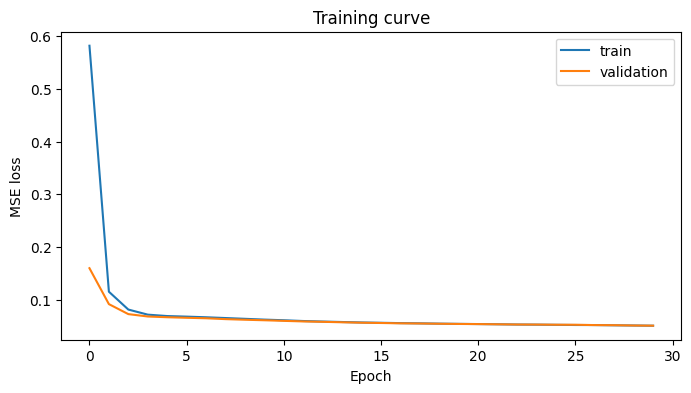

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.title("Training curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

## 5. Inspect reconstructions

A good latent representation should preserve the important shape of the time series, even if small details are smoothed.

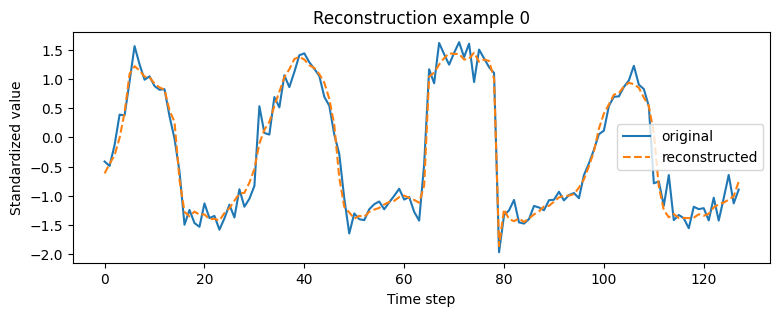

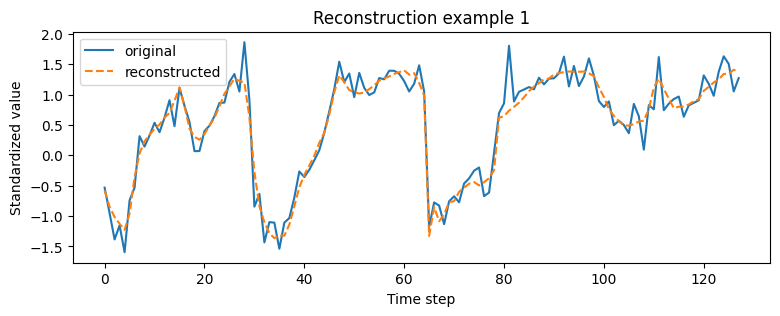

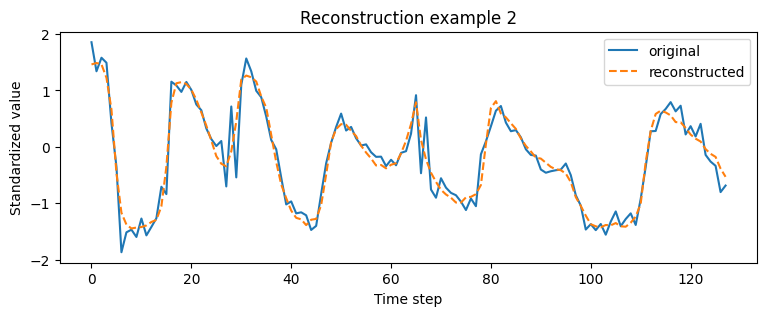

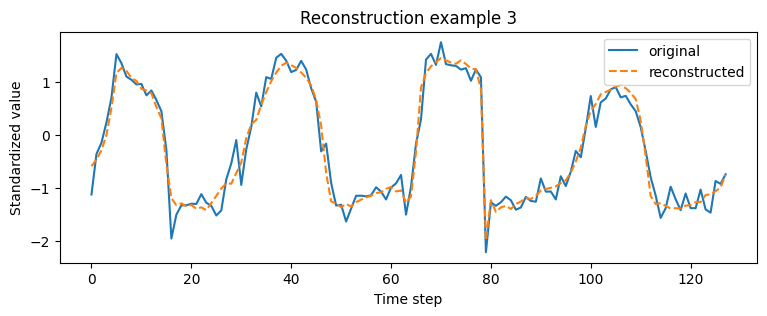

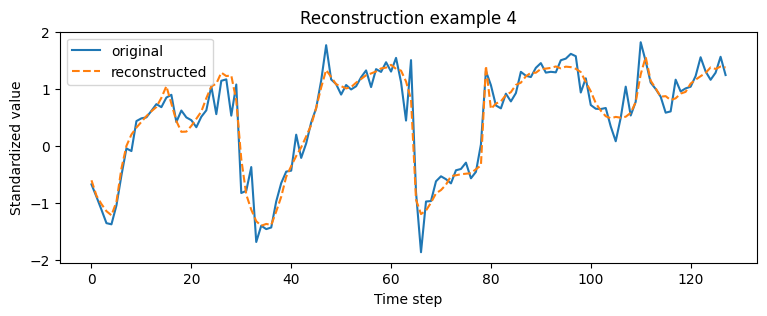

In [11]:
model.eval()
with torch.no_grad():
    sample = X_tensor[:8].to(device)
    recon, z = model(sample)

sample_np = sample.cpu().squeeze(1).numpy()
recon_np = recon.cpu().squeeze(1).numpy()

for i in range(5):
    plt.figure(figsize=(9, 3))
    plt.plot(sample_np[i], label="original")
    plt.plot(recon_np[i], label="reconstructed", linestyle="--")
    plt.title(f"Reconstruction example {i}")
    plt.xlabel("Time step")
    plt.ylabel("Standardized value")
    plt.legend()
    plt.show()

## 6. Extract low-dimensional embeddings

These are the compressed representations of the time series.
Each row corresponds to one original time series.

In [12]:
model.eval()
with torch.no_grad():
    Z = model.encode(X_tensor.to(device)).cpu().numpy()

Z.shape

(2700, 8)

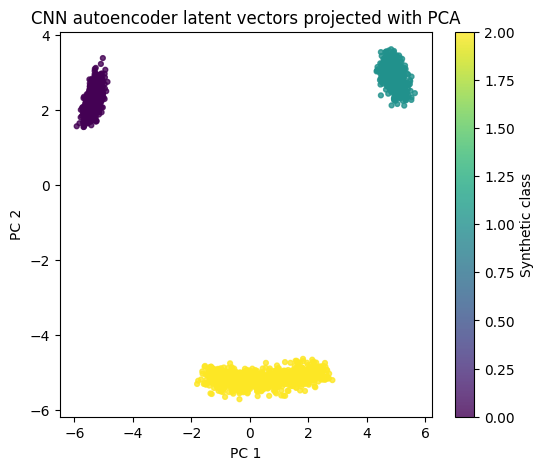

In [13]:
# Visualize the learned latent space in 2D using PCA
Z_2d = PCA(n_components=2).fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels, s=12, alpha=0.8)
plt.title("CNN autoencoder latent vectors projected with PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(scatter, label="Synthetic class")
plt.show()

## 7. How to use this with your own data

Replace the synthetic data block with your own array:

```python
X = your_data.astype(np.float32)
```

Expected shape before converting to PyTorch:

```python
X.shape == (n_samples, sequence_length)
```

Then run:

```python
X_scaled = scaler.fit_transform(X).astype(np.float32)
X_tensor = torch.tensor(X_scaled).unsqueeze(1)
```

For multichannel time series, for example temperature + humidity + pressure, use shape:

```python
X_tensor.shape == (n_samples, n_channels, sequence_length)
```

Then change the first convolution from:

```python
nn.Conv1d(1, 16, ...)
```

to:

```python
nn.Conv1d(n_channels, 16, ...)
```

## Notes for real geophysical / environmental time series

Useful extensions:

- mask missing values or interpolate before training
- add temporal metadata such as seasonality separately
- try larger latent dimensions such as 16, 32, or 64
- compare against PCA as a baseline
- use reconstruction error for anomaly detection
- train separate models for different station types or sensor types
- add denoising by corrupting the input and reconstructing the clean signal

For InSAR displacement time series, the latent vector can represent temporal behaviour such as linear trend, seasonal deformation, step-like changes, or non-stationary motion patterns.